<a href="https://colab.research.google.com/github/KlentZedlav/Portfolio/blob/main/Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: VISUALIZING RAW DATA (EDA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel('Data.xlsx')

# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '')

# -------------------------
# HISTOGRAMS
# -------------------------
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# -------------------------
# BOXPLOTS (OUTLIERS)
# -------------------------
df.plot(kind='box', subplots=True, layout=(4,4), figsize=(12,10))
plt.tight_layout()
plt.show()

# -------------------------
# SCATTER (Example: Years_of_Exp vs Salary)
# -------------------------
plt.scatter(df['Years_of_Exp'], df['Salary_USD'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary USD')
plt.title('Years of Exp vs Salary')
plt.show()

# -------------------------
# CORRELATION HEATMAP
# -------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Data.xlsx'

STEP 2: FEATURE IMPORTANCE

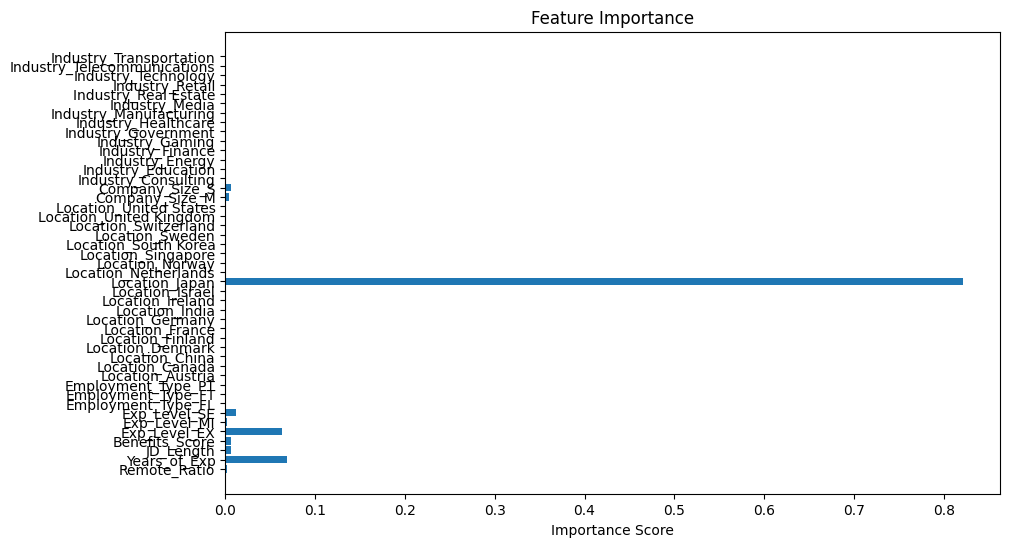

In [ ]:
# Drop Job Title (high cardinality problem)
df_model = df.drop('Job_Title', axis=1)

# Encode categorical variables
df_model = pd.get_dummies(df_model, drop_first=True)

# Split data
X = df_model.drop('Salary_USD', axis=1)
y = df_model['Salary_USD']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest for feature importance
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

# Plot importance
importance = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

STEP 3: MODEL PERFORMANCE VISUALIZATION

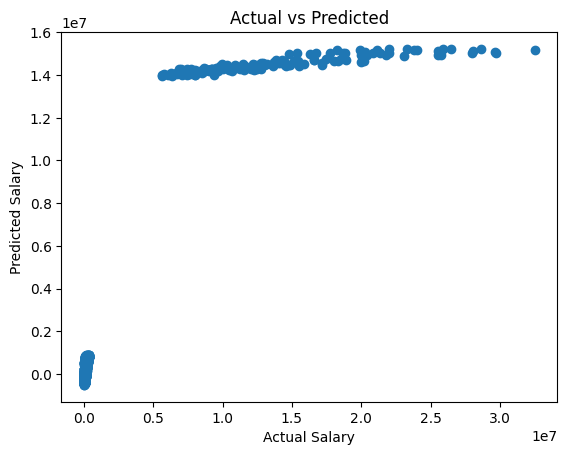

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -------------------------
# ACTUAL vs PREDICTED
# -------------------------
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

STEP 4: RESIDUAL ANALYSIS

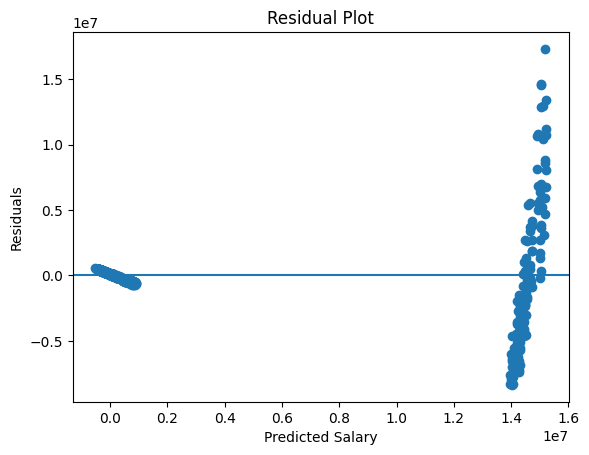

In [ ]:
# Residuals
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 1649595008222.259
R²: 0.8342875148041399
